# Data Analysis and Dataset Validation

## Objective

The objective of this notebook is to perform exploratory data analysis (EDA) and dataset validation on the annotated wildlife image dataset prior to training object detection models using the TensorFlow Object Detection API.

Specifically, this notebook:
- Analyses image resolution consistency
- Identifies potential preprocessing constraints
- Validates annotation completeness
- Prepares a clean, annotation-consistent dataset

These steps are critical to ensure stable training and avoid configuration mismatches in downstream model pipelines.


## Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import imread

## Image Resolution Analysis

Image resolution analysis was conducted to determine the variability in image dimensions across the dataset.

Object detection models in TensorFlow typically require a fixed input resolution during training. Significant variation in image sizes can:
- Increase preprocessing overhead
- Introduce aspect ratio distortion during resizing
- Affect anchor box performance and localisation accuracy

Understanding the resolution distribution informs decisions regarding model input shape and resizing strategy.


In [5]:
dim1 = []
dim2 = []
for image_filename in os.listdir('./images'):
    name, ext = os.path.splitext(image_filename)
    try:
        if not ext == '.xml':
            img = imread('./images/'+image_filename)
            d1,d2,color = img.shape
            dim1.append(d1)
            dim2.append(d2)
            
    except:
        print(image_filename)
        continue
    

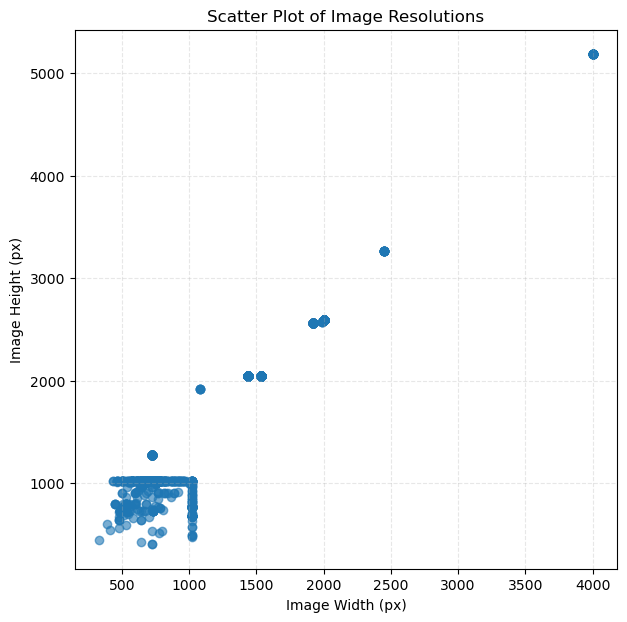

In [13]:
plt.figure(figsize=(7,7))
plt.scatter(dim1, dim2, alpha=0.6)
plt.xlabel("Image Width (px)")
plt.ylabel("Image Height (px)")
plt.title("Scatter Plot of Image Resolutions")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

### Image Resolution Distribution

The scatter plot shows the relationship between image width and height across the dataset. Most images are clustered within a resolution range of approximately 400–1000 pixels in width and 500–1100 pixels in height, indicating a relatively consistent set of image dimensions.

A small number of higher-resolution images are present as outliers, reaching widths of up to 4000 pixels and heights exceeding 5000 pixels. However, these do not dominate the dataset and are unlikely to negatively impact training when appropriate resizing is applied.


### Implications for Model Training

The dominant clustering of image resolutions suggests that a fixed input size can be applied during preprocessing without introducing significant distortion for the majority of samples. This supports the use of standard input resolutions commonly used by TensorFlow Object Detection models.

The presence of a small number of high-resolution outliers highlights the importance of consistent resizing during preprocessing. While these images may provide additional spatial detail, they could otherwise introduce computational inefficiencies or bias anchor box optimisation if left unprocessed.


## Width Distribution

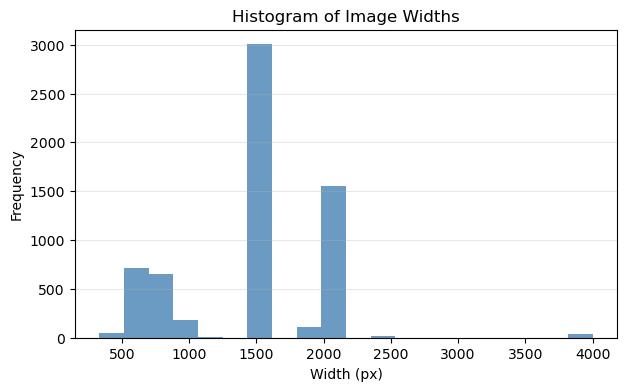

In [12]:
plt.figure(figsize=(7,4))
plt.hist(dim1, bins=20, color='steelblue', alpha=0.8)
plt.xlabel("Width (px)")
plt.ylabel("Frequency")
plt.title("Histogram of Image Widths")
plt.grid(axis='y', alpha=0.3)
plt.show()


### Image Width Distribution

The histogram shows that the majority of images fall within a width range of approximately 500 to 2000 pixels. Several peaks are visible, indicating that the dataset contains images captured at a small number of common resolutions rather than a continuous range.

This suggests that the dataset is derived from multiple acquisition sources or camera settings, which is common in real-world wildlife imagery.


## Height Distribution

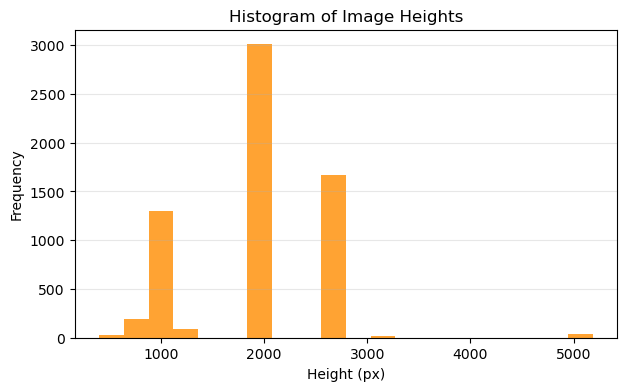

In [15]:
plt.figure(figsize=(7,4))
plt.hist(dim2, bins=20, color='darkorange', alpha=0.8)
plt.xlabel("Height (px)")
plt.ylabel("Frequency")
plt.title("Histogram of Image Heights")
plt.grid(axis='y', alpha=0.3)
plt.show()


### Image Height Distribution

The histogram shows that most images have heights between approximately 800 and 2500 pixels, with clear clustering around a small number of common resolutions. This mirrors the width distribution and suggests that images were captured using a limited set of camera configurations.

The distribution contains a small number of high-resolution outliers, extending beyond 5000 pixels in height, though these represent a minority of the dataset.


### Summary Statistics

Descriptive statistics were calculated to quantify the range and central tendency of image dimensions. These values provide empirical justification for selecting a fixed input size during model configuration.


In [16]:
print('Average Width: ' + str(np.mean(dim1)))

Average Width: 1448.1450007897647


In [17]:
print('Min Width: ', np.min(dim1))
print('Max Width: ', np.max(dim1))

Min Width:  332
Max Width:  4000


In [18]:
print('Average Height: ' + str(np.mean(dim2)))

Average Height: 1944.1306270731322


In [19]:
print('Min Height: ', np.min(dim2))
print('Max Height: ', np.max(dim2))

Min Height:  405
Max Height:  5184


## Annotation Consistency Validation

Before training an object detection model, it is essential to ensure that every annotated image has a corresponding XML file and vice versa.

Missing or mismatched annotations can result in:
- Training script failures
- Silent exclusion of samples
- Incorrect dataset statistics

This section verifies annotation completeness.


In [20]:
import os

image_dir = "./images"   

images = {}
xmls = {}

for f in os.listdir(image_dir):
    name, ext = os.path.splitext(f)
    
    if ext.lower() in [".jpg", ".jpeg", ".png"]:
        images[name] = f
    elif ext.lower() == ".xml":
        xmls[name] = f

print("Images found:", len(images))
print("XMLs found:", len(xmls))



Images found: 6336
XMLs found: 1500


## Creation of a Clean Annotated Dataset

To ensure dataset integrity, a clean subset was created containing only images with valid Pascal VOC XML annotations.

This step prevents unannotated images from being inadvertently included during TFRecord generation and model training.


In [21]:
import os
import shutil

src = "./images"                   # folder containing ALL images + XMLs
dst = "./annotated_images"         # new folder for CLEAN dataset

os.makedirs(dst, exist_ok=True)

# Collect basenames of annotated XML files
xml_files = [f for f in os.listdir(src) if f.endswith(".xml")]
xml_basenames = {os.path.splitext(f)[0] for f in xml_files}

copied = 0

for f in os.listdir(src):
    name, ext = os.path.splitext(f)
    if name in xml_basenames and ext.lower() in [".jpg", ".jpeg", ".png", ".xml"]:
        shutil.copy(os.path.join(src, f), os.path.join(dst, f))
        copied += 1

print("Copied files:", copied)
print("Annotated dataset ready at:", dst)


Copied files: 3000
Annotated dataset ready at: ./annotated_images


The resulting dataset contains only annotation-consistent image–XML pairs, ensuring reliable downstream preprocessing and training.


## Discussion

The exploratory analysis confirms that the dataset is suitable for object detection training, with manageable variation in image resolution and complete annotation coverage.

Although resizing will be required to satisfy TensorFlow model input constraints, no extreme resolution outliers were identified that would justify image exclusion or aggressive cropping. Instead, resolution variability can be addressed through controlled resizing during training, ensuring both computational efficiency and maximal data utilisation.

These findings support the use of standard model configurations from the TensorFlow Object Detection Model Zoo without the need for extensive custom preprocessing.

These conclusions directly inform the model selection, input resolution configuration, and training strategy explored in the subsequent notebook.
